# Análise Exploratória — Home Credit Default Risk

Objetivo: entender a base de **credit scoring** antes da modelagem (CRISP-DM — *Data Understanding*).
Insumo: `Dados/clean_data.csv` (gerado por `data_sanitization.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'DataPipeline' else Path.cwd()
df = pd.read_csv(ROOT / 'Dados' / 'clean_data.csv')
print(df.shape)
df.head()

(307511, 124)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.9,1.7
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.9,3.3
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.1,0.6
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52.0,8.3
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,54.6,8.3


## 1. Distribuição do target (desbalanceamento)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


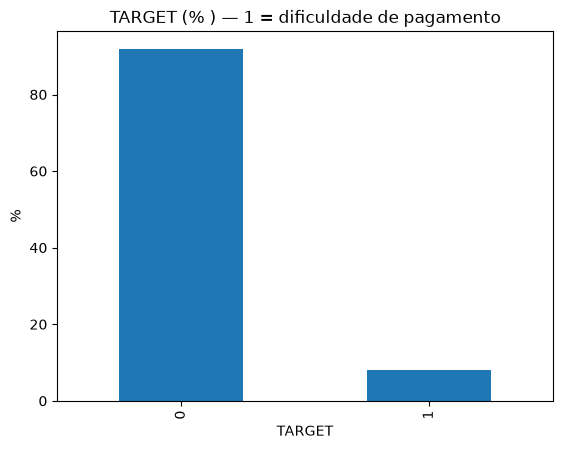

In [2]:
vc = df['TARGET'].value_counts(normalize=True) * 100
print(vc)
vc.plot(kind='bar', title='TARGET (% ) — 1 = dificuldade de pagamento')
plt.ylabel('%'); plt.show()

## 2. Qualidade dos dados — nulos

In [3]:
na = (df.isna().mean() * 100).sort_values(ascending=False)
na[na > 0].head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

## 3. Taxa de default por segmento

In [4]:
for col in ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']:
    rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100
    print(f'\n=== Default (%) por {col} ===')
    print(rate.round(2))


=== Default (%) por NAME_CONTRACT_TYPE ===
NAME_CONTRACT_TYPE
Cash loans         8.35
Revolving loans    5.48
Name: TARGET, dtype: float64

=== Default (%) por NAME_INCOME_TYPE ===
NAME_INCOME_TYPE
Maternity leave         40.00
Unemployed              36.36
Working                  9.59
Commercial associate     7.48
State servant            5.75
Pensioner                5.39
Businessman              0.00
Student                  0.00
Name: TARGET, dtype: float64

=== Default (%) por NAME_EDUCATION_TYPE ===
NAME_EDUCATION_TYPE
Lower secondary                  10.93
Secondary / secondary special     8.94
Incomplete higher                 8.48
Higher education                  5.36
Academic degree                   1.83
Name: TARGET, dtype: float64


## 4. Variáveis financeiras e idade vs. default

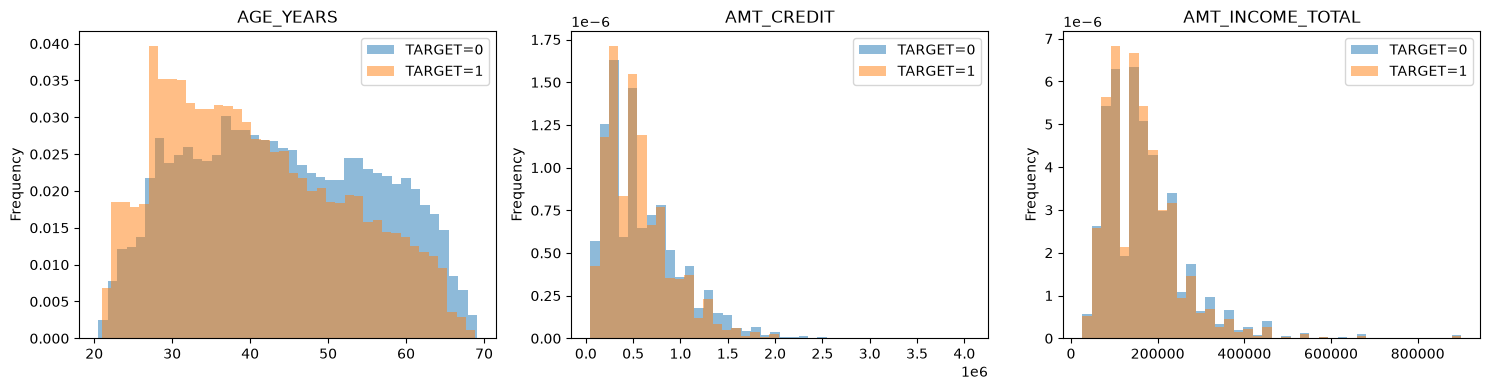

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['AGE_YEARS', 'AMT_CREDIT', 'AMT_INCOME_TOTAL']):
    for t in [0, 1]:
        df[df['TARGET'] == t][col].plot(kind='hist', bins=40, alpha=0.5, ax=ax, label=f'TARGET={t}', density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 5. Scores externos (EXT_SOURCE) — poder preditivo e cobertura

In [6]:
ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
print('Correlação com TARGET:')
print(df[ext + ['TARGET']].corr()['TARGET'].round(3))
print('\n% nulos:')
print((df[ext].isna().mean() * 100).round(1))

Correlação com TARGET:
EXT_SOURCE_1   -0.155
EXT_SOURCE_2   -0.160
EXT_SOURCE_3   -0.179
TARGET          1.000
Name: TARGET, dtype: float64

% nulos:
EXT_SOURCE_1    56.4
EXT_SOURCE_2     0.2
EXT_SOURCE_3    19.8
dtype: float64


## Conclusões para a modelagem

- **Desbalanceamento ~8%** → priorizar AUC/KS/recall; usar `is_unbalance`/`class_weight`.
- **Nulos relevantes** (EXT_SOURCE_1, dados do prédio) → imputação / LightGBM nativo.
- **EXT_SOURCE** são fortes preditores, mas com baixa cobertura → enriquecer com a ABT (histórico de bureau e pagamentos).
- **Segmentos** (tipo de contrato, educação, renda) mostram risco diferencial → boas features.